In [1]:
import scanpy as sc

In [2]:
import pandas as pd

In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [4]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [5]:
sc.set_figure_params(dpi=150, dpi_save=300)

In [6]:
adata = sc.read_h5ad( "integrated_scvi_uterus.h5ad", backed = 'r') 
adata

AnnData object with n_obs × n_vars = 960115 × 35103 backed at 'integrated_scvi_uterus.h5ad'
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors', 'predicted_doublet', 'Menstrual_stage_short', 'leiden', 'fine_celltype', 'broad

In [7]:
adata[adata.obs['Tissue_ROI'].str.contains('fluid')].obs['lineage'].value_counts()

lineage
immune         48546
mesenchymal    29000
epithelial      4236
endothelial       29
mesothelial        1
Name: count, dtype: int64

In [8]:
adata.obs['Menstrual_stage_short'] = np.where(
    adata.obs['Tissue_ROI'].str.contains('fluid'),
    'Menstrual fluid', 
    adata.obs['Menstrual_stage_short']
)

In [9]:
# add for donnors where Unknown 
# based on transcriptomics see `summarize_metadata.ipynb`

adata.obs['Menstrual_stage_short'] = np.where(
    adata.obs['Donor_id'] == 'BZ52_END_0_FTM_1 (Patient26)',
    'Proliferative', 
    adata.obs['Menstrual_stage_short']
)

adata.obs['Menstrual_stage_short'] = np.where(
    adata.obs['Donor_id'] == 'BZ62_END_0_FTM_1 (Control35)',
    'Secretory', 
    adata.obs['Menstrual_stage_short']
)

In [10]:
sorted(adata.obs['broad_celltype'].unique().tolist())

['Endo_artery',
 'Endo_cap',
 'Endo_lymp',
 'Endo_ven',
 'Epi_CervixSquamous',
 'Epi_EndoCil',
 'Epi_EndoGland',
 'Epi_EndoGlandBas',
 'Epi_EndoGlandFun',
 'Epi_EndoGlandLum',
 'Epi_EndoMucinous',
 'Immune_B_cells',
 'Immune_Conventional_DC',
 'Immune_Erythroid',
 'Immune_Granulocytes',
 'Immune_Haematopoietic_progenitor_cells',
 'Immune_ILC',
 'Immune_Macrophages',
 'Immune_Megakaryocytes/platelets',
 'Immune_Monocytes',
 'Immune_Myeloid_progenitors',
 'Immune_NK_cells',
 'Immune_Non-conventional_DC',
 'Immune_T_cells',
 'Mesen_AdvFibs',
 'Mesen_AdvFibsIntr',
 'Mesen_EndoGlandBas',
 'Mesen_EndoStromalFib',
 'Mesen_Pericyte',
 'Mesen_SMCs',
 'Mesen_vSMCs',
 'Meso_serosa',
 'Neural_Schwann']

In [11]:
map_broad = {'Endo_artery' : 'Endothelial',
 'Endo_cap' : 'Endothelial',
 'Endo_lymp' : 'Endothelial',
 'Endo_ven' : 'Endothelial',
 'Epi_CervixSquamous' : 'drop',
 'Epi_EndoCil' : 'Epithelial',
 'Epi_EndoGland' : 'Epithelial',
 'Epi_EndoGlandBas' : 'Epithelial',
 'Epi_EndoGlandFun' : 'Epithelial',
 'Epi_EndoGlandLum' : 'Epithelial',
 'Epi_EndoMucinous' : 'Epithelial',
 'Immune_B_cells' : 'Immune_Lymphoid',
 'Immune_Conventional_DC' : 'Immune_Myeloid',
 'Immune_Erythroid' : 'drop',
 'Immune_Granulocytes'  : 'Immune_Myeloid',
 'Immune_Haematopoietic_progenitor_cells' : 'drop',
 'Immune_ILC' : 'Immune_Lymphoid',
 'Immune_Macrophages' : 'Immune_Myeloid',
 'Immune_Megakaryocytes/platelets' : 'drop',
 'Immune_Monocytes': 'Immune_Myeloid',
 'Immune_Myeloid_progenitors' : 'drop', 
 'Immune_NK_cells'  : 'Immune_Lymphoid',
 'Immune_Non-conventional_DC' : 'Immune_Myeloid',
 'Immune_T_cells' : 'Immune_Lymphoid',
 'Mesen_AdvFibs' : 'Mesenchymal',
 'Mesen_AdvFibsIntr' : 'Mesenchymal',
 'Mesen_EndoGlandBas': 'Mesenchymal',
 'Mesen_EndoStromalFib': 'Mesenchymal',
 'Mesen_Pericyte' : 'Mesenchymal',
 'Mesen_SMCs': 'Mesenchymal', 
 'Mesen_vSMCs': 'Mesenchymal', 
 'Meso_serosa': 'drop', 
 'Neural_Schwann' : 'drop'
}

In [12]:
adata.obs['plot_ct'] = adata.obs['broad_celltype'].map(map_broad)

In [13]:
adata.obs['Menstrual_stage_short'] = pd.Categorical(
    adata.obs['Menstrual_stage_short'], 
    categories = [
    "Proliferative",
    "Secretory",
    "Menstrual",
    "Menstrual fluid",
    "Hormones",
    "Postmenopausal",
],
    ordered = True
)

/tmp/ipykernel_1766703/1166767247.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs.groupby(["Menstrual_stage_short", "plot_ct_broad"])


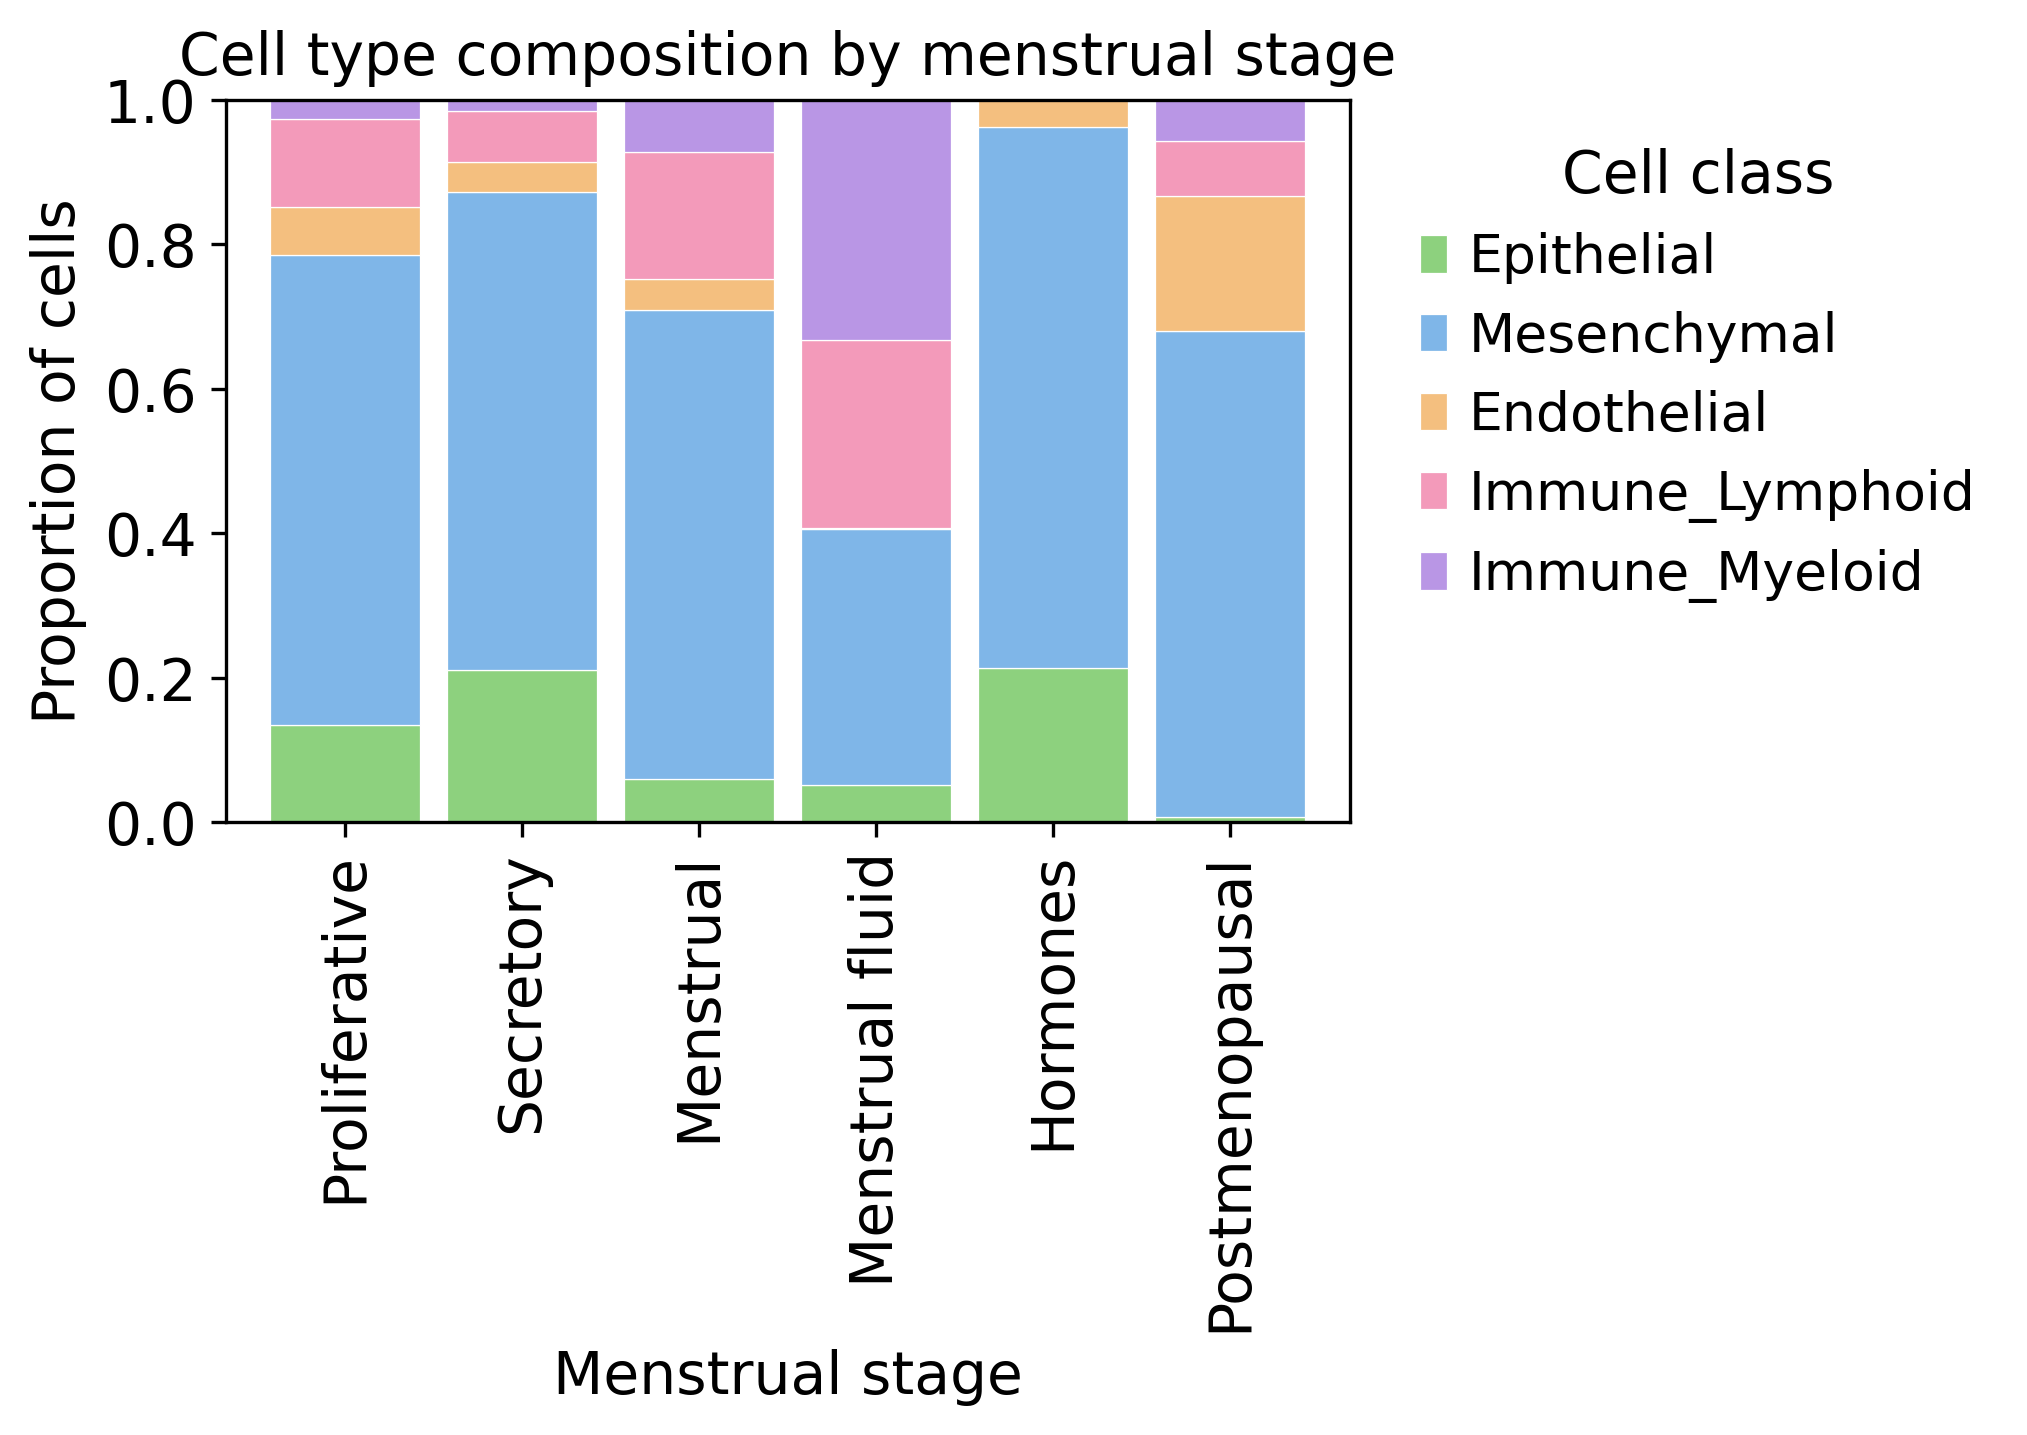

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plot_ct_palette = {
    "Epi_Cil": "#D6ED8B",
    "Epi_Gland": "#F4EE8E",
    "Epithelial": "#8DD17E",
    "Epi_Mucinous": "#68B38A",

    "Mesenchymal": "#7FB6E8",
    "Mesen_StromalFib": "#C7E0F4",

    "Endothelial": "#F4BF7F",

    "Immune_Lymphoid": "#F39ABA",
    "Immune_Myeloid": "#B996E5",
}

# IMPORTANT for backed AnnData:
# only pull the two obs columns into memory, not X
obs = adata.obs[["plot_ct", "Menstrual_stage_short"]].copy()

obs["plot_ct_broad"] = obs["plot_ct"]

# exclude dropped / unmapped cells
obs = obs.loc[
    obs["plot_ct_broad"].notna() & 
    (obs["plot_ct_broad"] != "drop")
].copy()

# counts per menstrual stage and cell class
counts = (
    obs.groupby(["Menstrual_stage_short", "plot_ct_broad"])
       .size()
       .unstack(fill_value=0)
)

# convert to proportions within each menstrual stage
props = counts.div(counts.sum(axis=1), axis=0)

# optional: choose a biologically sensible order
ct_order = [
    # "Epi_Cil",
    # "Epi_Gland",
    # "Epi_GlandBas",
    # "Epi_GlandFun",
    # "Epi_GlandLum",
    # "Epi_Mucinous",
    # "Mesen",
    # "Mesen_StromalFib",
    'Epithelial', 
    'Mesenchymal',
    "Endothelial",
    "Immune_Lymphoid",
    "Immune_Myeloid",
]
ct_order = [x for x in ct_order if x in props.columns]
props = props[ct_order]

colors = [plot_ct_palette[x] for x in props.columns]

ax = props.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(7, 5),
    width=0.85,
    edgecolor="white",
    linewidth=0.3
)
ax.grid(False)
ax.set_xlabel("Menstrual stage")
ax.set_ylabel("Proportion of cells")
ax.set_title("Cell type composition by menstrual stage")
ax.legend(
    title="Cell class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig('barplot_celltypes.pdf')
plt.show()

In [15]:
props

plot_ct_broad,Epithelial,Mesenchymal,Endothelial,Immune_Lymphoid,Immune_Myeloid
Menstrual_stage_short,,,,,
Proliferative,0.135043,0.649208,0.066988,0.121526,0.027235
Secretory,0.211436,0.661216,0.041369,0.070355,0.015623
Menstrual,0.059861,0.648582,0.043037,0.175362,0.073157
Menstrual fluid,0.051790,0.354558,0.000355,0.260979,0.332319
Hormones,0.214151,0.747598,0.038251,0.000000,0.000000
Postmenopausal,0.008040,0.672072,0.186421,0.075867,0.057600


In [16]:
0.260979 + 0.332319

0.593298